In [2]:
!pip install pytorch_lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.3/819.3 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 903.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 931.6/931.6 kB 54.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlin

In [3]:
import numpy as np
import torch
import torch.nn as nn
import pytorch_lightning as pl
import torch.optim as optim
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from torch.utils.data import DataLoader, TensorDataset, random_split

In [4]:
# Generate synthetic non-linear data with 3 variables
def generate_data(n_samples=1000):
    X1 = np.random.uniform(-5, 5, n_samples)
    X2 = np.random.uniform(-5, 5, n_samples)
    X3 = np.random.uniform(-5, 5, n_samples)

    # Complex non-linear equation with 3 variables
    y = (2 * np.sin(X1) + 0.5 * X2**2 + 0.3 * X3**3 +
         np.cos(X1 * X2) + np.random.normal(0, 0.2, n_samples))

    X = np.column_stack((X1, X2, X3))
    return torch.FloatTensor(X), torch.FloatTensor(y.reshape(-1, 1))

In [5]:
# Define a PyTorch Lightning-based 3-layer deep neural network
class LightningThreeLayerNN(pl.LightningModule):
    def __init__(self, input_size=3, hidden1_size=64, hidden2_size=32, output_size=1, lr=0.01):
        super(LightningThreeLayerNN, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden1_size)
        self.layer2 = nn.Linear(hidden1_size, hidden2_size)
        self.output_layer = nn.Linear(hidden2_size, output_size)
        self.relu = nn.ReLU()
        self.loss_fn = nn.MSELoss()
        self.lr = lr

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        return self.output_layer(x)

    def training_step(self, batch, batch_idx):
        X_batch, y_batch = batch
        y_pred = self(X_batch)
        loss = self.loss_fn(y_pred, y_batch)
        self.log('train_loss', loss)
        return loss

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.lr)


In [6]:
# Generate synthetic data
X, y = generate_data(1000)


In [7]:
# Split into training & validation sets
train_size = int(0.8 * len(X))
val_size = len(X) - train_size
train_data, val_data = random_split(TensorDataset(X, y), [train_size, val_size])

In [8]:
# Create data loaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)

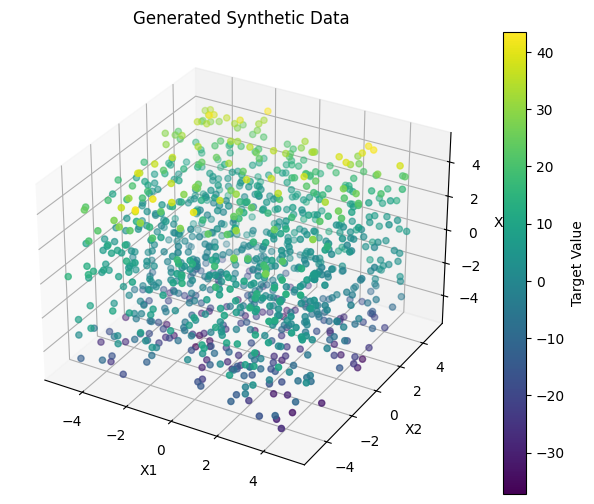

In [9]:
# Plot the generated synthetic data before training
def plot_synthetic_data(X, y):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y.numpy(), cmap='viridis')
    plt.colorbar(scatter, label='Target Value')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title('Generated Synthetic Data')
    plt.show()

plot_synthetic_data(X, y)

In [10]:
# Train the model using PyTorch Lightning
model = LightningThreeLayerNN()
trainer = pl.Trainer(max_epochs=100, log_every_n_steps=10)
trainer.fit(model, train_loader, val_loader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type    | Params | Mode 
-------------------------------------------------
0 | layer1       | Linear  | 256    | train
1 | layer2       | Linear  | 2.1 K  | train
2 | output_layer | Linear  | 33     | train
3 | relu         | ReLU    | 0      | train
4 | loss_fn      | MSELoss | 0      | train
-------------------------------------------------
2.4 K     Trainable params
0         Non-trainable params
2.4 K     Total params
0.009     Total estimated model params size (MB)
5         Modules in train mode
0     

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


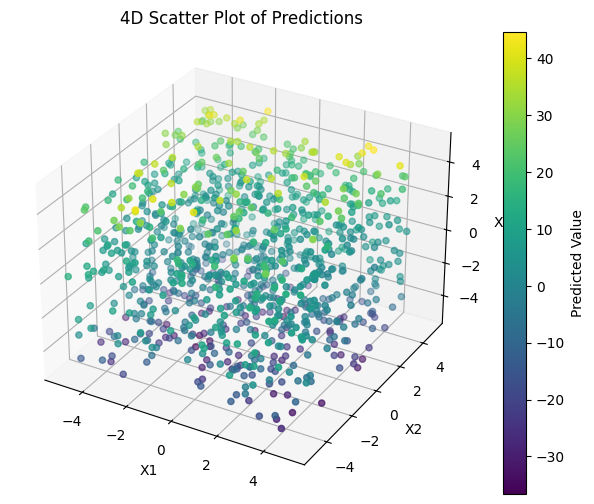

In [11]:
# Plot 4D scatter of predictions
def plot_4d_scatter(X, model):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    with torch.no_grad():
        y_pred = model(X)

    scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y_pred.numpy(), cmap='viridis')
    plt.colorbar(scatter, label='Predicted Value')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title('4D Scatter Plot of Predictions')
    plt.show()

plot_4d_scatter(X, model)

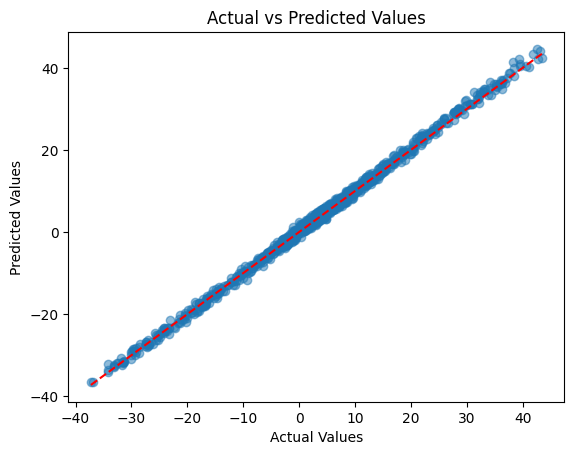

In [12]:
# Plot Actual vs. Predicted Values
def plot_actual_vs_predicted(y, model, X):
    with torch.no_grad():
        y_pred = model(X)

    plt.figure()
    plt.scatter(y.numpy(), y_pred.numpy(), alpha=0.5)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs Predicted Values')
    plt.show()

plot_actual_vs_predicted(y, model, X)

In [13]:
# Test the model with new data points
def test_model(model, x1, x2, x3):
    with torch.no_grad():
        x_tensor = torch.FloatTensor([[x1, x2, x3]])
        prediction = model(x_tensor)
        return prediction.item()

# Define test points
test_points = [(-4, -4, -4), (-2, -2, -2), (0, 0, 0), (2, 2, 2), (4, 4, 4)]

In [14]:
# Print test predictions
print("\nTest Predictions:")
for x1, x2, x3 in test_points:
    pred = test_model(model, x1, x2, x3)
    actual = 2 * np.sin(x1) + 0.5 * x2**2 + 0.3 * x3**3 + np.cos(x1 * x2)
    print(f"Input: ({x1}, {x2}, {x3})")
    print(f"Prediction: {pred:.3f}")
    print(f"Actual: {actual:.3f}\n")


Test Predictions:
Input: (-4, -4, -4)
Prediction: -11.909
Actual: -10.644

Input: (-2, -2, -2)
Prediction: -2.245
Actual: -2.872

Input: (0, 0, 0)
Prediction: 1.159
Actual: 1.000

Input: (2, 2, 2)
Prediction: 6.336
Actual: 5.565

Input: (4, 4, 4)
Prediction: 27.976
Actual: 24.729

